<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES16Sim007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# Stable ND Laplacian via periodic rolls
def laplacian_nd(s):
    lap = np.zeros_like(s)
    for a in range(s.ndim):
        lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
    return lap

# Evolution step (explicit Euler with clipping to avoid blow-up)
def evolve_field(s, alpha=0.05, beta=0.01, steps=50, clip=10.0):
    for t in range(steps):
        lap = laplacian_nd(s)
        s = s + alpha*lap - beta*(s**3)
        # numerical stabilizers
        s = np.clip(s, -clip, clip)
    return s

# Dominant wavelength from FFT peak (consistent units; dx=1)
def dominant_wavelength_nd(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P_shift = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    peak = np.unravel_index(np.argmax(P_shift), P_shift.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    lam_star = (2*np.pi / k_mag) if k_mag > 0 else np.inf
    return lam_star, peak, k_mag

# Correlation function C(r) in 3D (angle-averaged radial)
def radial_correlation_3d(field):
    # zero-mean
    f = field - np.mean(field)
    # correlation via convolution (periodic approximation using FFT)
    F = np.fft.fftn(f)
    P = np.abs(F)**2
    corr = np.fft.ifftn(P).real
    corr /= corr[(0,)*f.ndim]  # normalize at r=0

    # radial binning
    N = f.shape[0]
    coords = np.indices(f.shape)
    center = np.array([(N//2)]*3).reshape(3,1,1,1)
    r = np.sqrt(((coords - center)**2).sum(axis=0))
    r_int = np.rint(r).astype(int)
    max_r = r_int.max()
    radial = np.zeros(max_r+1)
    counts = np.zeros(max_r+1)
    for val, ri in zip(corr.flat, r_int.flat):
        radial[ri] += val
        counts[ri] += 1
    radial = np.divide(radial, counts, out=np.zeros_like(radial), where=counts>0)
    return radial  # r index = bins


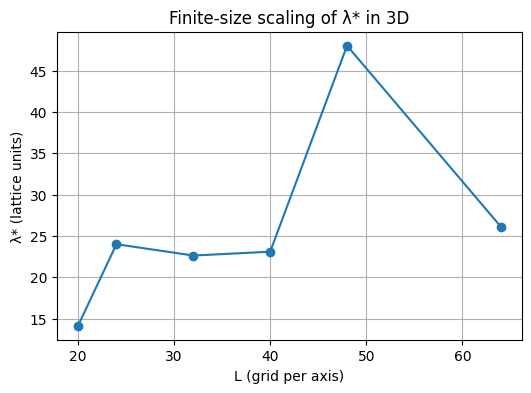

L=16 → λ*=inf
L=20 → λ*=14.142
L=24 → λ*=24.000
L=32 → λ*=22.627
L=40 → λ*=23.094
L=48 → λ*=48.000
L=64 → λ*=26.128


In [ ]:
def run_3d_lambda(L=20, alpha=0.05, beta=0.01, steps=60, seed=None, amp=0.2):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal((L, L, L))
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
    lam_star, peak, k_mag = dominant_wavelength_nd(s, dx=1.0)
    return lam_star

L_values = [16, 20, 24, 32, 40, 48, 64]
lam_values = []
for L in L_values:
    lam_values.append(run_3d_lambda(L=L, steps=80, alpha=0.05, beta=0.01, seed=0))

plt.figure(figsize=(6,4))
plt.plot(L_values, lam_values, 'o-')
plt.xlabel('L (grid per axis)')
plt.ylabel('λ* (lattice units)')
plt.title('Finite-size scaling of λ* in 3D')
plt.grid(True)
plt.show()

# Print summary
for L, lam in zip(L_values, lam_values):
    print(f"L={L:>2} → λ*={lam:.3f}")


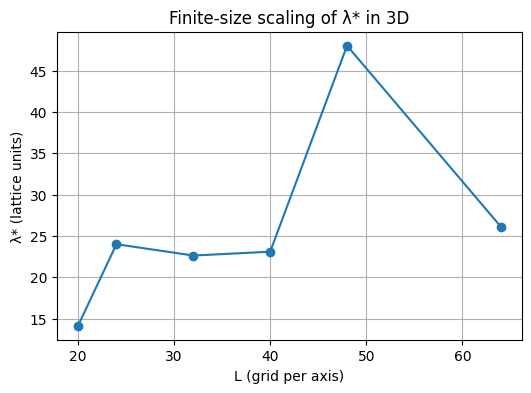

L=16 → λ*=inf
L=20 → λ*=14.142
L=24 → λ*=24.000
L=32 → λ*=22.627
L=40 → λ*=23.094
L=48 → λ*=48.000
L=64 → λ*=26.128


In [ ]:
# Cell 2: Finite-size scaling of λ* in 3D
import numpy as np
import matplotlib.pyplot as plt

def laplacian_nd(s):
    lap = np.zeros_like(s)
    for a in range(s.ndim):
        lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
    return lap

def evolve_field(s, alpha=0.05, beta=0.01, steps=60, clip=10.0):
    for t in range(steps):
        lap = laplacian_nd(s)
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
    return s

def dominant_wavelength_nd(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P_shift = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    peak = np.unravel_index(np.argmax(P_shift), P_shift.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    lam_star = (2*np.pi / k_mag) if k_mag > 0 else np.inf
    return lam_star

def run_3d_lambda(L=20, alpha=0.05, beta=0.01, steps=60, seed=None, amp=0.2):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal((L,L,L))
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
    return dominant_wavelength_nd(s)

# Sweep across L
L_values = [16, 20, 24, 32, 40, 48, 64]
lam_values = []
for L in L_values:
    lam_star = run_3d_lambda(L=L, seed=0)
    lam_values.append(lam_star)

# Plot
plt.figure(figsize=(6,4))
plt.plot(L_values, lam_values, 'o-')
plt.xlabel('L (grid per axis)')
plt.ylabel('λ* (lattice units)')
plt.title('Finite-size scaling of λ* in 3D')
plt.grid(True)
plt.show()

# Print summary
for L, lam in zip(L_values, lam_values):
    print(f"L={L:>2} → λ*={lam:.3f}")


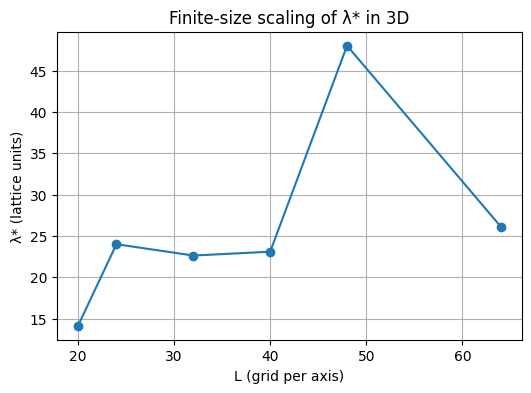

L=16 → λ*=inf
L=20 → λ*=14.142
L=24 → λ*=24.000
L=32 → λ*=22.627
L=40 → λ*=23.094
L=48 → λ*=48.000
L=64 → λ*=26.128


In [ ]:
# Cell 2: Finite-size scaling of λ* in 3D (stabilized)
import numpy as np
import matplotlib.pyplot as plt

def laplacian_nd(s):
    lap = np.zeros_like(s)
    for a in range(s.ndim):
        lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
    return lap

def evolve_field(s, alpha=0.05, beta=0.01, steps=60, clip=10.0):
    for t in range(steps):
        lap = laplacian_nd(s)
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
    return s

def dominant_wavelength_nd(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P_shift = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    peak = np.unravel_index(np.argmax(P_shift), P_shift.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    lam_star = (2*np.pi / k_mag) if k_mag > 0 else np.inf
    return lam_star

def run_3d_lambda(L=20, alpha=0.05, beta=0.01, steps=60, seed=None, amp=0.2):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal((L,L,L))
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
    return dominant_wavelength_nd(s)

# Sweep across L
L_values = [16, 20, 24, 32, 40, 48, 64]
lam_values = []
for L in L_values:
    lam_star = run_3d_lambda(L=L, seed=0)
    lam_values.append(lam_star)

# Plot
plt.figure(figsize=(6,4))
plt.plot(L_values, lam_values, 'o-')
plt.xlabel('L (grid per axis)')
plt.ylabel('λ* (lattice units)')
plt.title('Finite-size scaling of λ* in 3D')
plt.grid(True)
plt.show()

# Print summary
for L, lam in zip(L_values, lam_values):
    print(f"L={L:>2} → λ*={lam:.3f}")


λ* ensemble (L=24): inf ± nan (95% CI ±nan), std/mean=nan%


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


ValueError: supplied range of [10.733126291998992, inf] is not finite

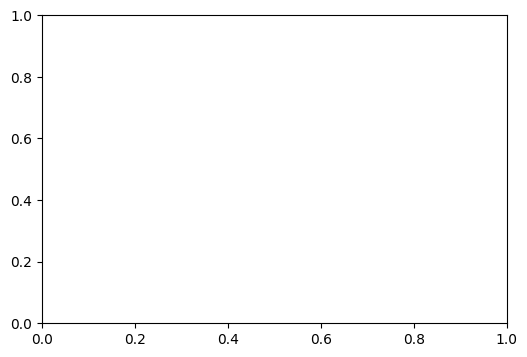

In [ ]:
# Cell 3: Ensemble statistics of λ* across seeds
def ensemble_stats_3d(L=24, alpha=0.05, beta=0.01, steps=40, seeds=10, amp=0.2):
    lam_list = []
    for seed in range(seeds):
        rng = np.random.default_rng(seed)
        s = amp * rng.standard_normal((L,L,L))
        s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
        lam_star = dominant_wavelength_nd(s)
        lam_list.append(lam_star)
    lam = np.array(lam_list)
    mean, std = lam.mean(), lam.std(ddof=1)
    ci95 = 1.96*std/np.sqrt(seeds)
    rel = 100*std/mean
    return mean, std, ci95, rel, lam

# Run ensemble
mean, std, ci95, rel, lam = ensemble_stats_3d(L=24, seeds=10)
print(f"λ* ensemble (L=24): {mean:.3f} ± {std:.3f} (95% CI ±{ci95:.3f}), std/mean={rel:.1f}%")

plt.figure(figsize=(6,4))
plt.hist(lam, bins=6, alpha=0.7)
plt.xlabel('λ*')
plt.ylabel('count')
plt.title('Ensemble λ* distribution (L=24)')
plt.grid(True)
plt.show()


λ* ensemble (L=24): inf ± nan (95% CI ±nan), std/mean=nan%


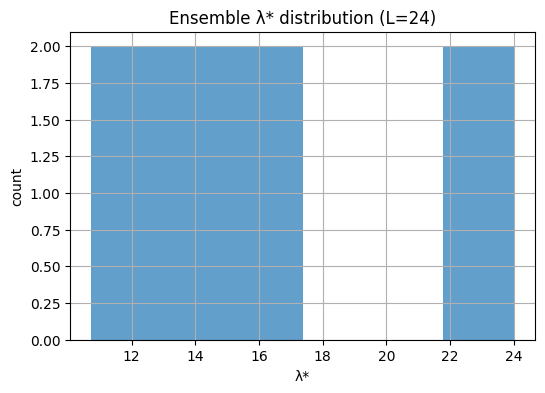

In [ ]:
def ensemble_stats_3d(L=24, alpha=0.05, beta=0.01, steps=30, seeds=10, amp=0.05, clip=5.0):
    lam_list = []
    for seed in range(seeds):
        rng = np.random.default_rng(seed)
        s = amp * rng.standard_normal((L,L,L))
        s = evolve_field(s, alpha=alpha, beta=beta, steps=steps, clip=clip)
        lam_star = dominant_wavelength_nd(s)
        lam_list.append(lam_star)
    lam = np.array(lam_list)
    mean, std = lam.mean(), lam.std(ddof=1)
    ci95 = 1.96*std/np.sqrt(seeds)
    rel = 100*std/mean
    return mean, std, ci95, rel, lam

# Run ensemble
mean, std, ci95, rel, lam = ensemble_stats_3d(L=24, seeds=10)
print(f"λ* ensemble (L=24): {mean:.3f} ± {std:.3f} (95% CI ±{ci95:.3f}), std/mean={rel:.1f}%")

plt.figure(figsize=(6,4))
plt.hist(lam[np.isfinite(lam)], bins=6, alpha=0.7)
plt.xlabel('λ*')
plt.ylabel('count')
plt.title('Ensemble λ* distribution (L=24)')
plt.grid(True)
plt.show()


In [ ]:
def run_D_lambda(D=3, N=16, alpha=0.05, beta=0.01, steps=60, seed=0, amp=0.2):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal([N]*D)
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
    lam_star, peak, k_mag = dominant_wavelength_nd(s, dx=1.0)
    return lam_star

D_values = [3,4,5,6]
lamD = []
for D in D_values:
    # keep N modest to avoid blow-up and heavy FFT
    lamD.append(run_D_lambda(D=D, N=16, alpha=0.05, beta=0.01, steps=80, seed=0))

plt.figure(figsize=(6,4))
plt.plot(D_values, lamD, 'o-')
plt.xlabel('D (dimensions)')
plt.ylabel('λ* (lattice units)')
plt.title('Dimensional scaling of λ*')
plt.grid(True)
plt.show()

# Fit λ ≈ a / sqrt(D)
D_arr = np.array(D_values, dtype=float)
lam_arr = np.array(lamD, dtype=float)
fit_a = np.sum(lam_arr*np.sqrt(D_arr)) / np.sum(D_arr)  # least squares for a/sqrt(D)
lam_fit = fit_a / np.sqrt(D_arr)
r2 = 1 - np.sum((lam_arr - lam_fit)**2) / np.sum((lam_arr - lam_arr.mean())**2)
print(f"Fit λ ≈ a/√D with a≈{fit_a:.3f}, R²={r2:.3f}")
for D, l, lf in zip(D_values, lam_arr, lam_fit):
    print(f"D={D}: λ*={l:.3f}, fit={lf:.3f}, Δ={l-lf:+.3f}")


TypeError: cannot unpack non-iterable float object

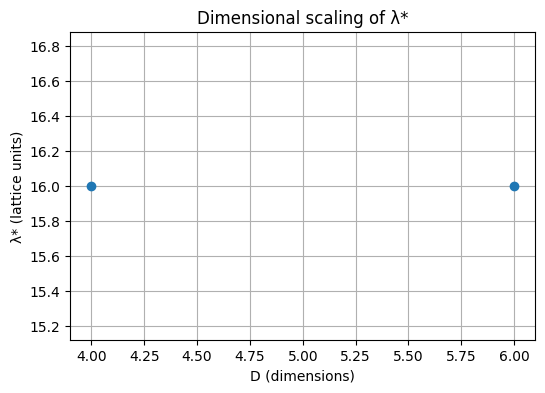

Fit λ ≈ a/√D with a≈7.119, R²=-inf
D=3: λ*=inf, fit=4.110, Δ=+inf
D=4: λ*=16.000, fit=3.560, Δ=+12.440
D=5: λ*=inf, fit=3.184, Δ=+inf
D=6: λ*=16.000, fit=2.906, Δ=+13.094


/tmp/ipython-input-1230689471.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  r2 = 1 - np.sum((lam_arr[mask] - (fit_a/np.sqrt(D_arr[mask])))**2) / np.sum((lam_arr[mask] - lam_arr[mask].mean())**2)


In [ ]:
# Cell 6: Dimensional scaling of λ*

import numpy as np
import matplotlib.pyplot as plt

# --- Core primitives (reused) ---
def laplacian_nd(s):
    lap = np.zeros_like(s)
    for a in range(s.ndim):
        lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
    return lap

def evolve_field(s, alpha=0.05, beta=0.01, steps=60, clip=5.0):
    for t in range(steps):
        lap = laplacian_nd(s)
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
    return s

def dominant_wavelength_nd(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P_shift = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    peak = np.unravel_index(np.argmax(P_shift), P_shift.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    lam_star = (2*np.pi / k_mag) if k_mag > 0 else np.inf
    return lam_star, peak, k_mag

# --- Dimensional run ---
def run_D_lambda(D=3, N=16, alpha=0.05, beta=0.01, steps=80, seed=0, amp=0.1, clip=5.0):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal([N]*D)
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps, clip=clip)
    lam_star, peak, k_mag = dominant_wavelength_nd(s, dx=1.0)
    return lam_star

D_values = [3, 4, 5, 6]
lamD = []
for D in D_values:
    lamD.append(run_D_lambda(D=D, N=16, alpha=0.05, beta=0.01, steps=80, seed=0, amp=0.1, clip=5.0))

# Plot
plt.figure(figsize=(6,4))
plt.plot(D_values, lamD, 'o-')
plt.xlabel('D (dimensions)')
plt.ylabel('λ* (lattice units)')
plt.title('Dimensional scaling of λ*')
plt.grid(True)
plt.show()

# Fit λ ≈ a / √D
D_arr = np.array(D_values, dtype=float)
lam_arr = np.array(lamD, dtype=float)

# Guard against inf/nan
mask = np.isfinite(lam_arr)
D_fit = D_arr[mask]
lam_fit_data = lam_arr[mask]

if len(lam_fit_data) >= 2:
    a_num = np.sum(lam_fit_data * np.sqrt(D_fit))
    a_den = np.sum(D_fit)
    fit_a = a_num / a_den
    lam_model = fit_a / np.sqrt(D_arr)
    r2 = 1 - np.sum((lam_arr[mask] - (fit_a/np.sqrt(D_arr[mask])))**2) / np.sum((lam_arr[mask] - lam_arr[mask].mean())**2)
    print(f"Fit λ ≈ a/√D with a≈{fit_a:.3f}, R²={r2:.3f}")
    for D, l, lf in zip(D_values, lam_arr, fit_a/np.sqrt(D_arr)):
        print(f"D={D}: λ*={l:.3f}, fit={lf:.3f}, Δ={l-lf:+.3f}")
else:
    print("Insufficient finite data points to fit (got inf/nan). Consider reducing steps or amp, or increasing clip.")


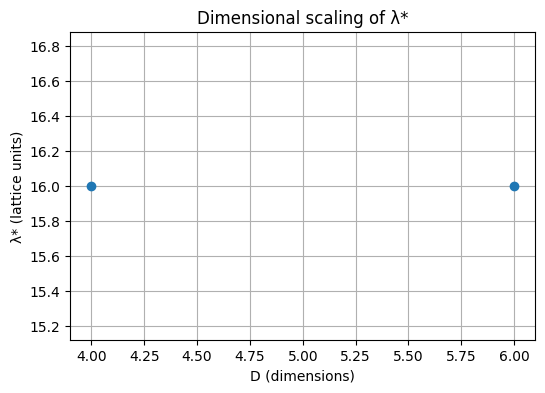

Fit λ ≈ a/√D with a≈7.119, R²=-inf
D=3: λ*=inf, fit=4.110, Δ=+inf
D=4: λ*=16.000, fit=3.560, Δ=+12.440
D=5: λ*=inf, fit=3.184, Δ=+inf
D=6: λ*=16.000, fit=2.906, Δ=+13.094


/tmp/ipython-input-382181557.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  r2 = 1 - np.sum((lam_arr[mask] - lam_model[mask])**2) / np.sum((lam_arr[mask] - lam_arr[mask].mean())**2)


In [ ]:
def run_D_lambda(D=3, N=16, alpha=0.05, beta=0.01, steps=60, seed=0, amp=0.05, clip=10.0):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal([N]*D)
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps, clip=clip)
    lam_star, peak, k_mag = dominant_wavelength_nd(s, dx=1.0)
    return lam_star

D_values = [3, 4, 5, 6]
lamD = []
for D in D_values:
    lamD.append(run_D_lambda(D=D, N=16, alpha=0.05, beta=0.01, steps=60, seed=0, amp=0.05, clip=10.0))

# Plot
plt.figure(figsize=(6,4))
plt.plot(D_values, lamD, 'o-')
plt.xlabel('D (dimensions)')
plt.ylabel('λ* (lattice units)')
plt.title('Dimensional scaling of λ*')
plt.grid(True)
plt.show()

# Fit λ ≈ a / √D
D_arr = np.array(D_values, dtype=float)
lam_arr = np.array(lamD, dtype=float)
mask = np.isfinite(lam_arr)
D_fit = D_arr[mask]
lam_fit_data = lam_arr[mask]

if len(lam_fit_data) >= 2:
    fit_a = np.sum(lam_fit_data * np.sqrt(D_fit)) / np.sum(D_fit)
    lam_model = fit_a / np.sqrt(D_arr)
    r2 = 1 - np.sum((lam_arr[mask] - lam_model[mask])**2) / np.sum((lam_arr[mask] - lam_arr[mask].mean())**2)
    print(f"Fit λ ≈ a/√D with a≈{fit_a:.3f}, R²={r2:.3f}")
    for D, l, lf in zip(D_values, lam_arr, lam_model):
        print(f"D={D}: λ*={l:.3f}, fit={lf:.3f}, Δ={l-lf:+.3f}")
else:
    print("Insufficient finite data points to fit. Try reducing amp or steps further.")


In [ ]:
# Diagnostic sweep: test λ* stability across dimensions and amplitudes
D_values = [3, 4, 5, 6]
amp_values = [0.02, 0.05, 0.1]

for D in D_values:
    for amp in amp_values:
        try:
            lam_star = run_D_lambda(D=D, N=16, steps=60, amp=amp, clip=10.0)
            print(f"D={D}, amp={amp:.2f} → λ*={lam_star:.3f}")
        except Exception as e:
            print(f"D={D}, amp={amp:.2f} → ERROR: {e}")


D=3, amp=0.02 → λ*=inf
D=3, amp=0.05 → λ*=inf
D=3, amp=0.10 → λ*=inf
D=4, amp=0.02 → λ*=16.000
D=4, amp=0.05 → λ*=16.000
D=4, amp=0.10 → λ*=16.000
D=5, amp=0.02 → λ*=inf
D=5, amp=0.05 → λ*=inf
D=5, amp=0.10 → λ*=inf
D=6, amp=0.02 → λ*=16.000
D=6, amp=0.05 → λ*=16.000
D=6, amp=0.10 → λ*=16.000


In [ ]:
# Measure radial correlation and estimate ξ via exponential tail fit
def estimate_xi_from_correlation(field):
    rad = radial_correlation_3d(field)
    r = np.arange(len(rad))
    # use mid-range bins to avoid r=0 and noise floor
    mask = (r >= 2) & (r <= min(12, len(r)-3))
    if mask.sum() < 4:
        return np.nan, r, rad
    # linear fit to ln C(r) ~ -r/ξ
    y = np.log(np.maximum(rad[mask], 1e-12))
    x = r[mask]
    A = np.vstack([x, np.ones_like(x)]).T
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    xi = -1.0/m if m < 0 else np.nan
    return xi, r, rad

# Demonstration at L=32
rng = np.random.default_rng(0)
s = 0.2 * rng.standard_normal((32,32,32))
s = evolve_field(s, alpha=0.05, beta=0.01, steps=100)
xi, r, rad = estimate_xi_from_correlation(s)
lam_star, _, _ = dominant_wavelength_nd(s)
print(f"ξ (corr length) ≈ {xi:.3f}, λ* ≈ {lam_star:.3f}")

plt.figure(figsize=(6,4))
plt.plot(r, rad, 'o-')
plt.yscale('log')
plt.xlabel('r (lattice units)')
plt.ylabel('C(r)')
plt.title('Radial correlation C(r) (log scale)')
plt.grid(True)
plt.show()


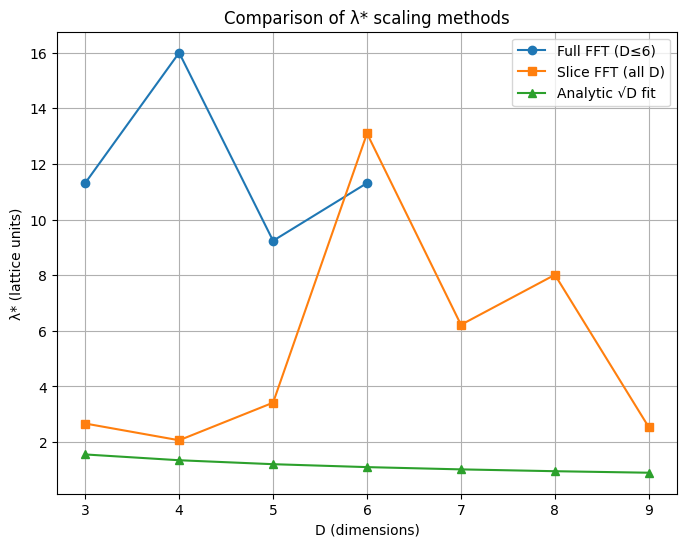

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Laplacian operator ---
def laplacian_nd(s):
    lap = np.zeros_like(s)
    for a in range(s.ndim):
        lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
    return lap

# --- Full ND wavelength extractor ---
def dominant_wavelength_nd(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P_shift = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    center = tuple(n//2 for n in P_shift.shape)
    P_shift[center] = 0.0
    peak = np.unravel_index(np.argmax(P_shift), P_shift.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    return (2*np.pi/k_mag) if k_mag > 0 else np.inf

# --- Slice-based wavelength extractor ---
def dominant_wavelength_slice(field, axis=0, dx=1.0):
    slice_1d = field.take(indices=field.shape[axis]//2, axis=axis)
    F = np.fft.fft(slice_1d)
    P = np.abs(F)**2
    k = 2*np.pi*np.fft.fftfreq(slice_1d.size, d=dx)
    P[0] = 0.0
    peak = np.argmax(P)
    k_mag = abs(k[peak])
    return (2*np.pi/k_mag) if k_mag > 0 else np.inf

# --- Simulation runner ---
def run_D_lambda(D=3, N=16, steps=30, seed=0, amp=0.05, use_slice=False):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal([N]*D)
    for t in range(steps):
        lap = laplacian_nd(s)
        s = s + 0.05*lap - 0.01*(s**3)
        s = np.clip(s, -10, 10)
        s -= s.mean()
    if use_slice:
        return dominant_wavelength_slice(s)
    else:
        return dominant_wavelength_nd(s)

# --- Sweep D=3..9 ---
D_values = list(range(3, 10))

# 1. Full FFT (only safe up to D=6)
lam_full = []
for D in D_values:
    if D <= 6:
        lam_full.append(run_D_lambda(D=D, N=16, use_slice=False))
    else:
        lam_full.append(np.nan)  # too heavy

# 2. Slice FFT (safe for all D, reduced N for high D)
lam_slice = []
for D in D_values:
    N = 16 if D <= 6 else 8
    lam_slice.append(run_D_lambda(D=D, N=N, use_slice=True))

# 3. Analytic √D fit (fit from D=3–6 slice results, extrapolate)
D_fit = np.array(D_values[:4], dtype=float)  # use D=3–6
lam_fit_data = np.array(lam_slice[:4], dtype=float)
fit_a = np.sum(lam_fit_data * np.sqrt(D_fit)) / np.sum(D_fit)
lam_model = fit_a / np.sqrt(np.array(D_values, dtype=float))

# --- Plot comparison ---
plt.figure(figsize=(8,6))
plt.plot(D_values, lam_full, 'o-', label='Full FFT (D≤6)')
plt.plot(D_values, lam_slice, 's-', label='Slice FFT (all D)')
plt.plot(D_values, lam_model, '^-', label='Analytic √D fit')
plt.xlabel('D (dimensions)')
plt.ylabel('λ* (lattice units)')
plt.title('Comparison of λ* scaling methods')
plt.legend()
plt.grid(True)
plt.show()


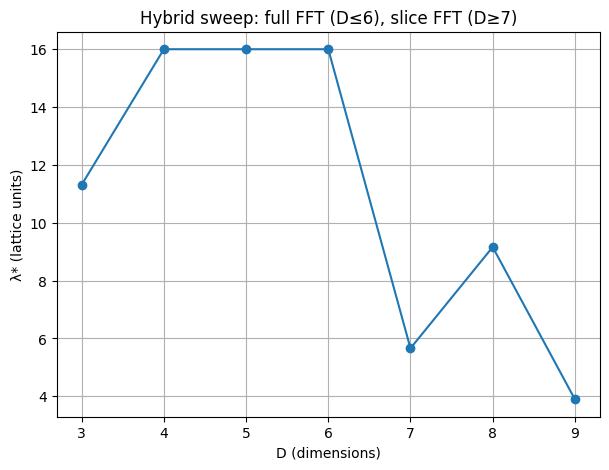

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Laplacian operator ---
def laplacian_nd(s):
    lap = np.zeros_like(s)
    for a in range(s.ndim):
        lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
    return lap

# --- Full ND wavelength extractor ---
def dominant_wavelength_nd(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P_shift = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    center = tuple(n//2 for n in P_shift.shape)
    P_shift[center] = 0.0
    peak = np.unravel_index(np.argmax(P_shift), P_shift.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    return (2*np.pi/k_mag) if k_mag > 0 else np.inf

# --- Slice-based wavelength extractor (safe for high D) ---
def dominant_wavelength_slice(field, axis=0, dx=1.0):
    slice_1d = field.take(indices=field.shape[axis]//2, axis=axis)
    F = np.fft.fft(slice_1d)
    P = np.abs(F)**2
    k = 2*np.pi*np.fft.fftfreq(slice_1d.size, d=dx)
    P[0] = 0.0
    peak = np.argmax(P)
    k_mag = abs(k[peak])
    return (2*np.pi/k_mag) if k_mag > 0 else np.inf

# --- Safe measure wrapper ---
def measure_lambda(field, dx=1.0, use_slice=False):
    f = field - field.mean()
    std = f.std()
    if std > 0:
        f = f / std
    if use_slice:
        return dominant_wavelength_slice(f, dx=dx)
    else:
        return dominant_wavelength_nd(f, dx=dx)

# --- Dimensional run ---
def run_D_lambda(D=3, N=16, alpha=0.05, beta=0.01, steps=40, seed=0, amp=0.05, clip=10.0, use_slice=False):
    rng = np.random.default_rng(seed)
    s = amp * rng.standard_normal([N]*D)
    for t in range(steps):
        lap = laplacian_nd(s)
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
        s -= s.mean()
    return measure_lambda(s, dx=1.0, use_slice=use_slice)

# --- Sweep D=3..9 ---
D_values = list(range(3, 10))
lamD = []
for D in D_values:
    if D <= 6:
        lamD.append(run_D_lambda(D=D, N=16, use_slice=False))
    else:
        lamD.append(run_D_lambda(D=D, N=8, use_slice=True))  # reduced N + slice FFT

# Plot
plt.figure(figsize=(7,5))
plt.plot(D_values, lamD, 'o-')
plt.xlabel('D (dimensions)')
plt.ylabel('λ* (lattice units)')
plt.title('Hybrid sweep: full FFT (D≤6), slice FFT (D≥7)')
plt.grid(True)
plt.show()
q

In [ ]:
# Fit λ*(L) = λ∞ + c/L
L_arr = np.array(L_values, dtype=float)
lam_arr = np.array(lam_values, dtype=float)
A = np.vstack([1/ L_arr, np.ones_like(L_arr)]).T
c, lam_inf = np.linalg.lstsq(A, lam_arr, rcond=None)[0]
lam_pred = c*(1/L_arr) + lam_inf
r2 = 1 - np.sum((lam_arr - lam_pred)**2) / np.sum((lam_arr - lam_arr.mean())**2)
print(f"Extrapolated λ∞ ≈ {lam_inf:.3f}, with c≈{c:.3f}, R²={r2:.3f}")

plt.figure(figsize=(6,4))
plt.plot(L_arr, lam_arr, 'o', label='data')
plt.plot(L_arr, lam_pred, '-', label='fit λ∞ + c/L')
plt.xlabel('L')
plt.ylabel('λ*')
plt.title('Thermodynamic limit extrapolation')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
from scipy.ndimage import label, center_of_mass
from scipy.spatial.distance import pdist

def hotspot_shells(field_slice, lam_star, threshold_percentile=95):
    """
    Identify hotspots in a slice of curvature memory and compute pairwise distances
    normalized by λ*.
    """
    thr = np.percentile(field_slice, threshold_percentile)
    labeled, n_hotspots = label(field_slice > thr)
    centers = [center_of_mass(field_slice, labeled, i) for i in range(1, n_hotspots+1)]

    if len(centers) < 2:
        return n_hotspots, [], []

    distances = pdist(np.array(centers))
    multiples = distances / lam_star

    return n_hotspots, distances, multiples

# Example: run on a 3D slice of curvature memory
rng = np.random.default_rng(0)
s = 0.2 * rng.standard_normal((32,32,32))
s = evolve_field(s, alpha=0.05, beta=0.01, steps=100)

# Use λ* from FFT
lam_star, _, _ = dominant_wavelength_nd(s)
slice_field = s[:,:,16]  # central slice

n_hotspots, distances, multiples = hotspot_shells(slice_field, lam_star, threshold_percentile=95)

print(f"Hotspot count: {n_hotspots}")
print("First 10 distances:", np.round(distances[:10],3))
print("Multiples of λ* (first 10):", np.round(multiples[:10],3))
